# baseline

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

In [167]:
import os
import joblib
import json
from datetime import datetime

class ModelManager:
    def __init__(self, base_dir='models'):
        self.base_dir = base_dir
        if not os.path.exists(self.base_dir):
            os.makedirs(self.base_dir)

    def save(self, model, model_name, metadata=None):
        # 1. 모델 저장 (.pkl)
        model_path = os.path.join(self.base_dir, f"{model_name}.pkl")
        joblib.dump(model, model_path)
        
        # 2. 메타데이터 저장 (.json)
        if metadata:
            meta_path = os.path.join(self.base_dir, f"{model_name}_meta.json")
            with open(meta_path, 'w', encoding='utf-8') as f:
                json.dump(metadata, f, indent=4, ensure_ascii=False)
        
        print(f"모델 [{model_name}] 저장 완료! (경로: {self.base_dir})")

    def list_models(self):
        models = []
        for file in os.listdir(self.base_dir):
            if file.endswith("_meta.json"):
                with open(os.path.join(self.base_dir, file), 'r', encoding='utf-8') as f:
                    meta = json.load(f)
                    models.append({
                        'model_name': file.replace("_meta.json", ""),
                        'custom': meta
                    })
        return models

# 객체 생성 
mm = ModelManager(base_dir='../../models/chj')

In [168]:
# 1. 데이터 로드

df = pd.read_csv("../../data/processed/ljh_preprocessed.csv")

In [169]:
# 전처리

cols_to_drop = ['user_id', 'reg_date', 'first_deposit', 'first_bet', 'country_id']
df_clean = df.drop(columns=cols_to_drop)

In [170]:
# 결측치 처리
# 기본 정보(성별, 연령대)가 없는 행 제거
df_clean = df_clean.dropna(subset=['gender', 'age_group'])
 
#활동 정보(hit_days, win_rate 등)가 없는 경우 0으로 채움 (활동 없음을 의미)
df_clean = df_clean.fillna(0)

In [171]:
# 특성(X)과 타겟(y) 분리
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

In [172]:
y.value_counts()

churn
0    33321
1    13016
Name: count, dtype: int64

In [173]:
# 학습/테스트 데이터 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [174]:
# 스케일링 (로지스틱 회귀는 스케일링 필수)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [175]:
# 모델 학습 및 평가 

dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train, y_train)
dummy_score = dummy_model.score(X_test, y_test)

print(f"Baseline Model Accuracy: {dummy_score:.4f}")

Baseline Model Accuracy: 0.7191


In [176]:
# 2. Logistic Regression Model (로지스틱 회귀)
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

/opt/miniconda3/envs/2nd/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [177]:
# 예측
y_pred = lr_model.predict(X_test_scaled)

In [178]:
# 예측 확률 (ROC-AUC)
y_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

In [179]:
# 평가 결과 출력
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)  

print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")  # 
print("-" * 50)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.8057
ROC-AUC Score: 0.8636
--------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      6665
           1       0.66      0.65      0.65      2603

    accuracy                           0.81      9268
   macro avg       0.76      0.76      0.76      9268
weighted avg       0.81      0.81      0.81      9268



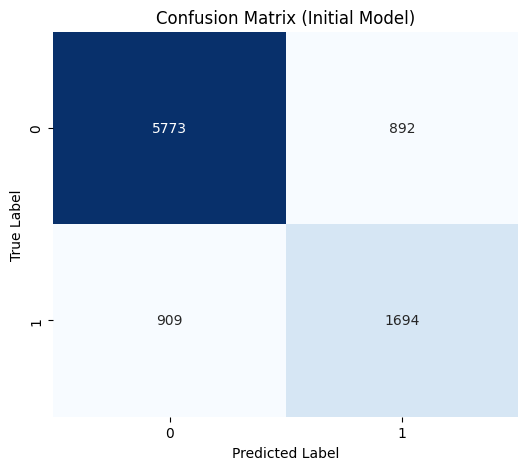

array([[5773,  892],
       [ 909, 1694]])

In [180]:
cm_initial = confusion_matrix(y_test, y_pred) 

# 2. 히트맵 그리기
plt.figure(figsize=(6, 5))
sns.heatmap(cm_initial, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Initial Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

cm_initial

# 하이퍼 파라미터 튜닝  
- 그리드 서치 

In [181]:
# 1. 튜닝할 파라미터 설정
# 'C': 규제 강도 (값이 작을수록 규제가 강함 = 모델이 단순해짐, 값이 클수록 규제가 약함 = 모델이 복잡해짐)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs'], 
    'max_iter': [1000]   
}

In [182]:
# 2. GridSearchCV 설정
# cv=5: 데이터를 5개로 쪼개서 교차 검증 (과적합 방지)
# scoring='roc_auc': 평가 기준을 ROC-AUC 점수로 설정 (불균형 데이터에 유리)
grid_search = GridSearchCV(LogisticRegression(random_state=42), 
                           param_grid, 
                           cv=5, 
                           #scoring='roc_auc', 
                           #scoring='recall',
                           scoring='f1',
                           n_jobs=-1) 

In [183]:
# 3. 학습 수행 (최적의 파라미터 찾기)

grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'max_iter': [1000], 'solver': ['lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displaye

In [184]:
# 결과 확인

print(f"최적의 파라미터 (Best Params): {grid_search.best_params_}")
print(f"최고 f1 점수 (Best CV Score): {grid_search.best_score_:.4f}")

최적의 파라미터 (Best Params): {'C': 100, 'max_iter': 1000, 'solver': 'lbfgs'}
최고 f1 점수 (Best CV Score): 0.6564


In [185]:
results_df = pd.DataFrame(grid_search.cv_results_)

# 2. 성능 순위(rank_test_score) 기준 상위 5개 추출
# 필요한 컬럼(파라미터, 평균 점수, 순위)만 선택해서 보기 좋게 출력
top_5_results = results_df[['params', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score').head(5)

top_5_results

,params,mean_test_score,rank_test_score
5,"{'C': 100, 'max_iter': 1000, 'solver': 'lbfgs'}",0.656420,1
4,"{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}",0.656417,2
3,"{'C': 1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.653786,3
2,"{'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}",0.648164,4
1,"{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}",0.609900,5


In [186]:
# 최적의 모델 저장
best_model = grid_search.best_estimator_

# 테스트 데이터로 예측
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

In [187]:
print("Option: Tuned Logistic Regression Performance")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_best):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_best))

Option: Tuned Logistic Regression Performance
Accuracy: 0.8056
ROC-AUC: 0.8638
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      6665
           1       0.65      0.65      0.65      2603

    accuracy                           0.81      9268
   macro avg       0.76      0.76      0.76      9268
weighted avg       0.81      0.81      0.81      9268



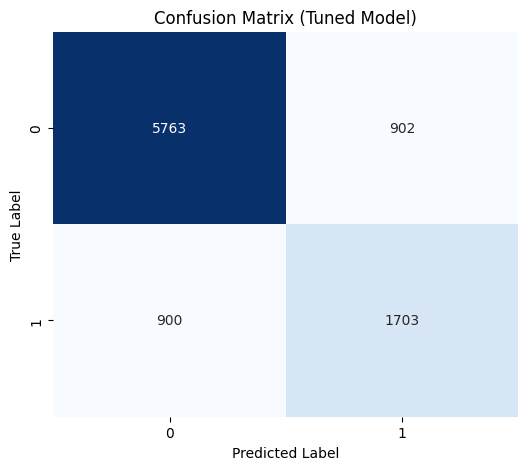

array([[5763,  902],
       [ 900, 1703]])

In [188]:
# confusion_matrix

cm = confusion_matrix(y_test, y_pred_best)

# 시각화
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix (Tuned Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

cm

# 특성 중요도

In [189]:
# 1. 특성 중요도(회귀 계수) 추출
# lr_model.coef_[0] : 각 특성에 곱해지는 가중치(계수)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

In [190]:
# 2. 절대값 기준으로 정렬하거나, 값의 크기 순으로 정렬
# 해석을 위해 값의 크기 순(양수/음수)으로 정렬합니다.
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=True)

In [191]:
# 3. 상위 중요 특성 출력
print("--- 이탈 확률을 높이는 주요 요인 (Top 5 Positive) ---")
print(feature_importance.sort_values(by='Coefficient', ascending=False).head(5))

print("\n--- 이탈 확률을 낮추는 주요 요인 (Top 5 Negative) ---")
print(feature_importance.head(5))

--- 이탈 확률을 높이는 주요 요인 (Top 5 Positive) ---
              Feature  Coefficient
14     fixed_hit_days     2.599796
15      live_hit_days     1.775588
11  fixed_active_days     1.772165
20      fixed_avg_roi     1.390126
6     live_win_amount     0.963763

--- 이탈 확률을 낮추는 주요 요인 (Top 5 Negative) ---
              Feature  Coefficient
13  total_active_days    -9.521548
3     live_bet_amount    -0.884653
4    total_bet_amount    -0.580711
12   live_active_days    -0.355808
9        live_bet_cnt    -0.285538


In [192]:
# 1. 최종 예측 및 확률 계산 (변수명 확인!)
y_pred_final = grid_search.predict(X_test_scaled)
y_proba_final = grid_search.predict_proba(X_test_scaled)[:, 1]

# 2. 성능 지표 계산
final_metrics = {
    'accuracy':  accuracy_score(y_test, y_pred_final),
    'precision': precision_score(y_test, y_pred_final, zero_division=0),
    'recall':    recall_score(y_test, y_pred_final, zero_division=0),
    'f1_score':  f1_score(y_test, y_pred_final, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, y_proba_final),
}

# 3. 모델 저장 (mm.save)
# rs.bestparams -> grid_search.best_params_ 로 수정
# rs.bestscore -> grid_search.best_score_ 로 수정
mm.save(
    grid_search.best_estimator_, 
    'logistic_regression_final', 
    metadata={
        **final_metrics,
        'best_params':      grid_search.best_params_,    # 최적 파라미터
        'best_cv_auc':      grid_search.best_score_,     # CV 최고 점수
        'best_threshold':   0.5,                         # 로지스틱 기본 임계값
        'features':         X.columns.tolist(),          # 사용된 피처
        'n_features':       X.shape[1],
        'train_size':       len(X_train),
        'test_size':        len(X_test),
        'scale_pos_weight': 1.0                          # 로지스틱은 보통 1.0
    }
)

# 4. 결과 출력
print('\n=== 저장된 모델 목록 ===')
for m in mm.list_models():
    name   = m.get('model_name', 'N/A')
    custom = m.get('custom', {})
    f1     = custom.get('f1_score', 0)
    auc    = custom.get('roc_auc', 0)
    thresh = custom.get('best_threshold', 0.5)
    print(f'  [{name}]  F1={f1:.4f}  |  ROC-AUC={auc:.4f}  |  threshold={thresh:.4f}')

모델 [logistic_regression_final] 저장 완료! (경로: ../../models/chj)

=== 저장된 모델 목록 ===
  [logistic_regression_final]  F1=0.6540  |  ROC-AUC=0.8638  |  threshold=0.5000
